# 结构化提取：device_info 中 OS 操作系统信息统计

本 notebook 用于从 `device_info` 字段（JSON 字符串格式）中提取 `os` 操作系统信息，并按不同操作系统统计请求数分布。

In [1]:
import pandas as pd
import json
import ast

In [2]:
# 读取数据
df = pd.read_csv('large_data.csv')
print(f"数据总行数：{len(df)}")
print(f"\ndevice_info 字段样例：")
print(df['device_info'].head(3).tolist())

数据总行数：1000000

device_info 字段样例：
['{"os": "Windows", "browser": "Chrome", "version": "85.3.29", "screen": "1440x900", "language": "zh-CN", "timezone": "UTC+0"}', '{"os": "macOS", "browser": "Safari", "version": "86.1.48", "screen": "1920x1080", "language": "ja-JP", "timezone": "UTC+9"}', '{"os": "Windows", "browser": "Chrome", "version": "122.3.98", "screen": "2560x1440", "language": "zh-CN", "timezone": "UTC+0"}']


In [3]:
# 定义解析 device_info 的函数
def extract_os(device_info):
    """从 device_info JSON 字符串中提取 os 字段"""
    if pd.isna(device_info):
        return None
    try:
        # 尝试直接解析 JSON
        info = json.loads(device_info)
        return info.get('os', None)
    except (json.JSONDecodeError, TypeError):
        # 如果直接解析失败，尝试用 ast.literal_eval 解析
        try:
            info = ast.literal_eval(device_info)
            return info.get('os', None)
        except (ValueError, SyntaxError):
            return None

In [4]:
# 提取 os 信息到新列
print("正在提取 os 信息...")
df['os'] = df['device_info'].apply(extract_os)
print(f"\n提取完成！")
print(f"\nos 字段样例：")
print(df[['device_info', 'os']].head())

正在提取 os 信息...



提取完成！

os 字段样例：
                                         device_info       os
0  {"os": "Windows", "browser": "Chrome", "versio...  Windows
1  {"os": "macOS", "browser": "Safari", "version"...    macOS
2  {"os": "Windows", "browser": "Chrome", "versio...  Windows
3  {"os": "macOS", "browser": "Firefox", "version...    macOS
4  {"os": "Android", "browser": "Edge", "version"...  Android


In [5]:
# 统计不同操作系统的请求数分布
os_counts = df['os'].value_counts()
print("\n=== 操作系统请求数分布 ===")
print(os_counts)


=== 操作系统请求数分布 ===
os
iOS        200454
Linux      200196
Android    199937
Windows    199829
macOS      199584
Name: count, dtype: int64


In [6]:
# 计算各操作系统占比
total_count = len(df)
os_percentage = (os_counts / total_count * 100).round(4)

# 合并显示次数和占比
os_stats = pd.DataFrame({
    'count': os_counts.values,
    'percentage(%)': os_percentage.values
}, index=os_counts.index)

print("\n=== 操作系统统计（含占比）===")
print(os_stats)


=== 操作系统统计（含占比）===
          count  percentage(%)
os                            
iOS      200454        20.0454
Linux    200196        20.0196
Android  199937        19.9937
Windows  199829        19.9829
macOS    199584        19.9584


In [7]:
# 检查是否有解析失败的记录
null_os_count = df['os'].isna().sum()
print(f"\n=== 解析失败的记录 ===")
print(f"os 为 null 的记录数：{null_os_count} 条")
print(f"占比：{null_os_count / total_count * 100:.4f}%")


=== 解析失败的记录 ===
os 为 null 的记录数：0 条
占比：0.0000%


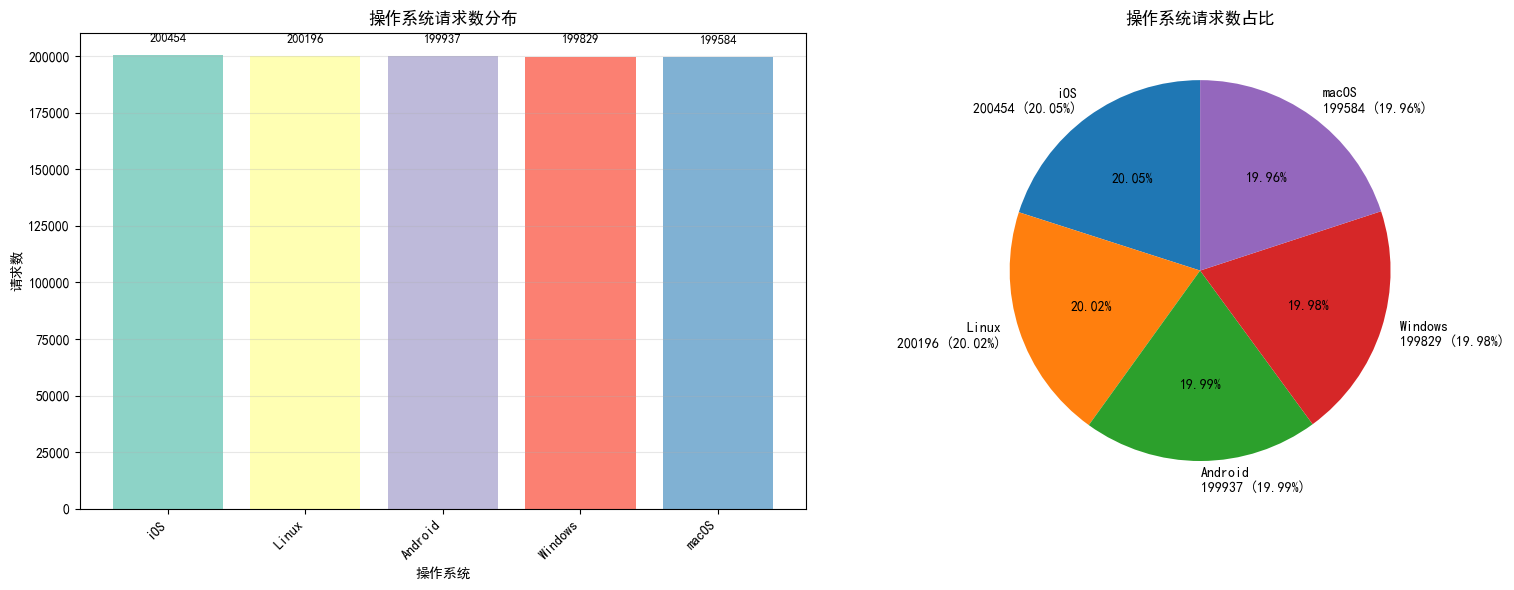


图表已保存为 os_distribution.png


In [8]:
# 可视化展示
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 图 1：操作系统请求数柱状图
colors = plt.cm.Set3(range(len(os_counts)))
bars = axes[0].bar(range(len(os_counts)), os_counts.values, color=colors)
axes[0].set_xticks(range(len(os_counts)))
axes[0].set_xticklabels(os_counts.index, rotation=45, ha='right')
axes[0].set_title('操作系统请求数分布')
axes[0].set_xlabel('操作系统')
axes[0].set_ylabel('请求数')
axes[0].grid(axis='y', alpha=0.3)

# 在柱状图上添加数值标签
for bar, count in zip(bars, os_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
                f'{count}', ha='center', va='bottom', fontsize=9)

# 图 2：操作系统占比饼图
pie_labels = [f'{os}\n{count} ({count/total_count*100:.2f}%)' 
              for os, count in zip(os_counts.index, os_counts.values)]
axes[1].pie(os_counts.values, labels=pie_labels, autopct='%1.2f%%', startangle=90)
axes[1].set_title('操作系统请求数占比')

plt.tight_layout()
plt.savefig('os_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n图表已保存为 os_distribution.png")

In [9]:
# 进一步分析：各操作系统下的 event_type 分布
print("\n=== 各操作系统下的 event_type 分布（交叉分析）===")
os_event_crosstab = pd.crosstab(df['os'], df['event_type'])
print(os_event_crosstab)


=== 各操作系统下的 event_type 分布（交叉分析）===


event_type  LogIn  ckick  clic  click  clik  cllick  log-out  login  login   \
os                                                                            
Android       116    115   120  32760   150     116      177  32883     148   
Linux         160    109   153  33034   124     136      149  32972     113   
Windows       123    112   118  32656   142     123      170  32971     135   
iOS           110    138   121  32857   125     124      164  32832     122   
macOS         114    119   128  32739   132     130      161  32788     121   

event_type  logn  ...  purchse  purhcase  seach  search  serach  serch  vew  \
os                ...                                                         
Android      123  ...      185       167    166   32780     149    171  162   
Linux        103  ...      160       177    194   32813     158    179  171   
Windows      138  ...      163       149    173   33081     139    185  158   
iOS          134  ...      202       171    138   3